In [35]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import copy, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import xarray as xr
import cfgrib
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [36]:
# ── CONSTANTS ─────────────────────────────────────────────────────────────────
MODEL_PATH    = 'saved_models/best_precip_model_1940.pt'
LAG           = 24
HORIZON       = 24
FINAL_EPOCHS  = 5
BATCH         = 128
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
os.remove(r'C:\Users\maili\Desktop\KU\AppMachineLearning\Final_Project\data\grid-timeseries_sel_vars_1940.grib.5b7b6.idx')

In [12]:
datasets = cfgrib.open_datasets("C:\\Users\\maili\\Desktop\\KU\\AppMachineLearning\\Final_Project\\data\\grid-timeseries_sel_vars_1940.grib")
ds0, ds1 = datasets

ref_lat  = ds0.latitude
ref_lon  = ds0.longitude
ref_time = ds0.time

channels, chan_names = [], []

for var in ['sp', 'tcc', 'u10', 'v10', 't2m']:
    channels.append(ds0[var].values.astype(np.float32))
    chan_names.append(var)


c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili

In [37]:
for var in ['ssrd', 'tp']:
    # find which dataset contains this variable
    ds_acc = None
    for ds in datasets:
        if var in ds.data_vars:
            ds_acc = ds
            break
    if ds_acc is None:
        print(f"WARNING: {var} not found in any dataset!")
        continue

    arr = ds_acc[var]  # shape: (time, step, lat, lon)
    print(f"{var} dims: {arr.dims}, shape: {arr.shape}")
    
    # deaccumulate along step, then take the last step (= 12h total)
    # or sum the diffs to get total over all steps
    arr_deacc = arr.diff(dim='step')          # per-hour amounts
    arr_total = arr.isel(step=-1)             # last step = total accumulated over 12h

    arr_daily = xr.DataArray(
        arr_total.values.astype(np.float32),
        coords={'time': ds_acc[var].time.values,
                'latitude': ref_lat,
                'longitude': ref_lon},
        dims=['time', 'latitude', 'longitude']
    )
    arr_h = arr_daily.reindex(time=ref_time, method='ffill').ffill(dim='time').bfill(dim='time')
    channels.append(arr_h.values.astype(np.float32))
    chan_names.append(var)

ssrd dims: ('time', 'step', 'latitude', 'longitude'), shape: (732, 12, 5, 5)
tp dims: ('time', 'step', 'latitude', 'longitude'), shape: (732, 12, 5, 5)


In [38]:
X_raw = np.stack(channels, axis=1).astype(np.float32)
tp_idx = chan_names.index('tp')

y_raw = channels[tp_idx].copy()

# clean NaNs
#for i in range(X_raw.shape[1]):
   # m = np.nanmean(X_raw[:, i])
    #X_raw[:, i] = np.nan_to_num(X_raw[:, i], nan=m)
#y_raw = np.nan_to_num(y_raw, nan=np.nanmean(y_raw))

# log transform
y_raw = np.log1p(y_raw * 1000)
X_raw[:, tp_idx] = np.log1p(X_raw[:, tp_idx] * 1000)

N = X_raw.shape[0]
N_FEATURES = X_raw.shape[1]


In [39]:
# ── 4. WINDOWS ────────────────────────────────────────────────────────────────
def make_windows(X, y, lag=LAG, horizon=HORIZON):
    idx = np.arange(lag, len(X) - horizon)
    Xw = np.stack([X[i-lag:i] for i in idx]).astype(np.float32)
    yw = np.stack([y[i+horizon] for i in idx]).astype(np.float32)
    return Xw, yw


X_all_w, y_all = make_windows(X_raw, y_raw)

train_end_w = int(0.70 * len(X_all_w))
val_end_w   = int(0.85 * len(X_all_w))

X_train_w, y_train = X_all_w[:train_end_w],          y_all[:train_end_w]
X_val_w,   y_val   = X_all_w[train_end_w:val_end_w], y_all[train_end_w:val_end_w]
X_test_w,  y_test  = X_all_w[val_end_w:],            y_all[val_end_w:]

In [42]:
def fit_scale(Xw):
    # Xw shape: (N, lag, C, H, W)
    # compute mean/std per channel, over N, lag, H, W
    mean = Xw.mean(axis=(0, 1, 3, 4))  # shape: (C,)
    std  = Xw.std(axis=(0, 1, 3, 4)) + 1e-8  # shape: (C,)
    return mean, std

def transform(Xw, sc):
    m, s = sc
    # broadcast (C,) over (N, lag, C, H, W)
    return ((Xw - m[None, None, :, None, None]) / 
             s[None, None, :, None, None]).astype(np.float32)

scaler = fit_scale(X_train_w)
X_tr_sc = transform(X_train_w, scaler)
X_te_sc = transform(X_test_w, scaler)
X_va_sc = transform(X_val_w, scaler)
y_tr, y_te, y_va = y_train, y_test, y_val


In [57]:
# ── 6. DATASET ────────────────────────────────────────────────────────────────
class SeqDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

def loader(X, y, shuffle):
    return DataLoader(SeqDS(X, y), batch_size=BATCH, shuffle=shuffle)

# ── 7. MODEL ──────────────────────────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hidden, ks=3):
        super().__init__()
        self.hidden = hidden
        self.conv = nn.Conv2d(in_ch + hidden, 4 * hidden, ks, padding=ks//2)

    def forward(self, x, h, c):
        i, f, o, g = self.conv(torch.cat([x, h], dim=1)).chunk(4, dim=1)

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)

        c = f * c + i * g
        h = o * torch.tanh(c)

        return h, c

class ConvLSTMModel(nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.2):
        super().__init__()
        self.hidden = hidden
        self.cell = ConvLSTMCell(in_ch, hidden)
        self.norm = nn.GroupNorm(8, hidden)
        self.drop = nn.Dropout2d(dropout)  # spatial dropout, suits conv outputs
        self.head = nn.Sequential(
            nn.Conv2d(hidden, hidden, 3, padding=1),
            nn.ReLU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(hidden, hidden // 2, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden // 2, 1, 1)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        h = torch.zeros(B, self.hidden, H, W, device=x.device)
        c = torch.zeros(B, self.hidden, H, W, device=x.device)
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)
        h = self.norm(h)
        h = self.drop(h)        # ← dropout after norm, before head
        return self.head(h).squeeze(1)

In [48]:
# ── LOSS ──────────────────────────────────────────────────────────────────────
def rain_loss(pred, target):
    weight = 1.0 + 5.0 * (target > 0).float()
    mse = (weight * (pred - target) ** 2).mean()
    mae = (weight * torch.abs(pred - target)).mean()
    return 0.7 * mse + 0.3 * mae  # combined

In [ ]:

# ── 8. HYPERPARAM SEARCH ──────────────────────────────────────────────────────
def train_and_eval(hidden, lr):
    model = ConvLSTMModel(N_FEATURES, hidden).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    tr_loader = loader(X_tr_sc, y_tr, True)
    va_loader = loader(X_va_sc, y_va, False)

    best_val = float("inf")

    for _ in range(6):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)

            opt.zero_grad()
            loss = rain_loss(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        vals = []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb, yb = xb.to(device), yb.to(device)
                vals.append(rain_loss(model(xb), yb).item())

        best_val = min(best_val, np.mean(vals))

    return best_val

param_grid = {
    "hidden": [32, 64, 128],
    "lr": [1e-3, 3e-4, 1e-4],
}

best_score = float("inf")
best_params = None

for h in param_grid["hidden"]:
    for lr in param_grid["lr"]:
        score = train_and_eval(h, lr)

        print(f"h={h}, lr={lr} → {score:.5f}")

        if score < best_score:
            best_score = score
            best_params = (h, lr)

print("\nBEST:", best_params)



KeyboardInterrupt: 

In [60]:
import optuna
import numpy as np
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Small subset for speed ─────────────────────────────────────────────────────
n = int(0.2 * len(X_tr_sc))
X_tr_small = X_tr_sc[:n]
y_tr_small = y_tr[:n]

# ── Objective ─────────────────────────────────────────────────────────────────
def objective(trial):
    hidden  = trial.suggest_categorical("hidden", [64, 128])
    lr      = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.4)

    model = ConvLSTMModel(N_FEATURES, hidden, dropout).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)

    tr_loader = loader(X_tr_small, y_tr_small, True)
    va_loader = loader(X_va_sc, y_va, False)

    best_val = float("inf")
    patience, no_imp = 3, 0

    for epoch in range(8):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            rain_loss(model(xb), yb).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            val = np.mean([
                rain_loss(model(xb.to(device)), yb.to(device)).item()
                for xb, yb in va_loader
            ])

        if val < best_val:
            best_val = val
            no_imp = 0
        else:
            no_imp += 1

        trial.report(val, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if no_imp >= patience:
            break

    return best_val

# ── Run study ─────────────────────────────────────────────────────────────────
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=3)
)
study.optimize(objective, n_trials=3, show_progress_bar=True)

# ── Results ───────────────────────────────────────────────────────────────────
best_hidden  = study.best_params["hidden"]
best_lr      = study.best_params["lr"]
best_dropout = study.best_params["dropout"]

print(f"\nBest params:  hidden={best_hidden}, lr={best_lr:.6f}, dropout={best_dropout:.3f}")
print(f"Best val loss: {study.best_value:.5f}")

  0%|          | 0/3 [00:00<?, ?it/s]


Best params:  hidden=64, lr=0.000819, dropout=0.231
Best val loss: 0.17577


In [ ]:
#best_hidden = 128
#best_lr = 1e-5

model = ConvLSTMModel(N_FEATURES, best_hidden).to(device)
opt = torch.optim.Adam(model.parameters(), lr=best_lr)
tr_loader = loader(X_tr_sc, y_tr, True)
va_loader = loader(X_va_sc, y_va, False)

best_val = float("inf")
best_state = copy.deepcopy(model.state_dict())
train_losses, val_losses = [], []

# ── early stopping params
PATIENCE = 2
patience_counter = 0

for epoch in range(FINAL_EPOCHS):
    model.train()
    tl = []
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = rain_loss(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # you were missing this in final training
        opt.step()
        tl.append(loss.item())
    train_losses.append(np.mean(tl))

    model.eval()
    vl = []
    with torch.no_grad():
        for xb, yb in va_loader:
            xb, yb = xb.to(device), yb.to(device)
            vl.append(rain_loss(model(xb), yb).item())
    val = np.mean(vl)
    val_losses.append(val)
    print(f"Epoch {epoch+1}: train={train_losses[-1]:.5f}, val={val:.5f}")

    if val < best_val:
        best_val = val
        best_state = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), MODEL_PATH)
        patience_counter = 0  # reset on improvement
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_state)
print(f"Loaded best model with val loss: {best_val:.5f}")

In [52]:
print(study.best_params["dropout"])

NameError: name 'study' is not defined

In [51]:
model.load_state_dict(best_state)
print(f"Loaded best model with val loss: {best_val:.5f}")

Loaded best model with val loss: 0.20770


           TEST SET METRICS
  MAE          : 0.1080 mm
  RMSE         : 0.2695 mm
  Bias         : -0.0397 mm
  Correlation  : 0.0684
---------------------------------------------
  POD (recall) : 0.1806  (fraction of rain events caught)
  FAR          : 0.8399  (fraction of rain alarms that are false)
  CSI          : 0.0927  (overall skill, 1=perfect)


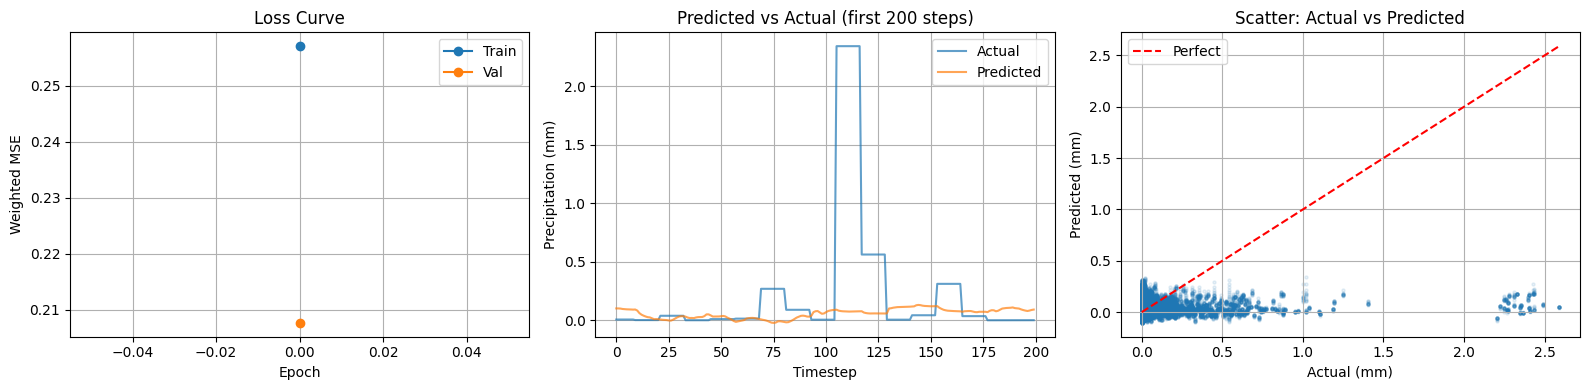

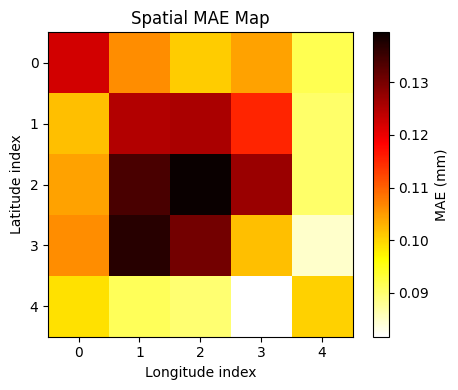

In [55]:
# ── EVALUATION ────────────────────────────────────────────────────────────────
model.eval()
# ── collect predictions on test set
all_preds, all_targets = [], []
te_loader = loader(X_te_sc, y_te, shuffle=False)

with torch.no_grad():
    for xb, yb in te_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()  # (B, H, W)
        all_preds.append(pred)
        all_targets.append(yb.numpy())

preds   = np.concatenate(all_preds,   axis=0)  # (N, 5, 5)
targets = np.concatenate(all_targets, axis=0)  # (N, 5, 5)

# ── inverse log transform → back to mm
preds_mm   = np.expm1(preds)   / 1000
targets_mm = np.expm1(targets) / 1000

# ── flatten spatial for scalar metrics
preds_flat   = preds_mm.reshape(-1)
targets_flat = targets_mm.reshape(-1)

# ── 1. SCALAR METRICS ─────────────────────────────────────────────────────────
mae  = mean_absolute_error(targets_flat, preds_flat)
rmse = np.sqrt(mean_squared_error(targets_flat, preds_flat))
bias = (preds_flat - targets_flat).mean()

# correlation
corr = np.corrcoef(targets_flat, preds_flat)[0, 1]

# skill scores for rain detection (binary)
threshold = 0.1 / 1000  # 0.1 mm threshold for "rain event"
pred_rain   = preds_flat   > threshold
target_rain = targets_flat > threshold

hits        = (pred_rain  & target_rain).sum()
misses      = (~pred_rain & target_rain).sum()
false_alarm = (pred_rain  & ~target_rain).sum()
correct_neg = (~pred_rain & ~target_rain).sum()

pod  = hits / (hits + misses + 1e-8)          # probability of detection
far  = false_alarm / (hits + false_alarm + 1e-8)  # false alarm ratio
csi  = hits / (hits + misses + false_alarm + 1e-8)  # critical success index

print("=" * 45)
print("           TEST SET METRICS")
print("=" * 45)
print(f"  MAE          : {mae*1000:.4f} mm")
print(f"  RMSE         : {rmse*1000:.4f} mm")
print(f"  Bias         : {bias*1000:.4f} mm")
print(f"  Correlation  : {corr:.4f}")
print("-" * 45)
print(f"  POD (recall) : {pod:.4f}  (fraction of rain events caught)")
print(f"  FAR          : {far:.4f}  (fraction of rain alarms that are false)")
print(f"  CSI          : {csi:.4f}  (overall skill, 1=perfect)")
print("=" * 45)

# ── 2. TRAINING CURVE ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(train_losses, label='Train', marker='o')
axes[0].plot(val_losses,   label='Val',   marker='o')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted MSE')
axes[0].legend()
axes[0].grid(True)

# ── 3. PREDICTED VS ACTUAL (spatial mean over grid) ───────────────────────────
pred_ts   = preds_mm.mean(axis=(1,2))    * 1000  # mean over 5×5 grid → mm
target_ts = targets_mm.mean(axis=(1,2)) * 1000

axes[1].plot(target_ts[:200], label='Actual',    alpha=0.7)
axes[1].plot(pred_ts[:200],   label='Predicted', alpha=0.7)
axes[1].set_title('Predicted vs Actual (first 200 steps)')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].legend()
axes[1].grid(True)

# ── 4. SCATTER PLOT ───────────────────────────────────────────────────────────
axes[2].scatter(targets_flat * 1000, preds_flat * 1000, alpha=0.1, s=5)
axes[2].plot([0, targets_flat.max()*1000],
             [0, targets_flat.max()*1000], 'r--', label='Perfect')
axes[2].set_title('Scatter: Actual vs Predicted')
axes[2].set_xlabel('Actual (mm)')
axes[2].set_ylabel('Predicted (mm)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150)
plt.show()

# ── 5. SPATIAL ERROR MAP ──────────────────────────────────────────────────────
mae_map = np.abs(preds_mm - targets_mm).mean(axis=0) * 1000  # (5, 5) in mm

fig2, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(mae_map, cmap='hot_r')
plt.colorbar(im, ax=ax, label='MAE (mm)')
ax.set_title('Spatial MAE Map')
ax.set_xlabel('Longitude index')
ax.set_ylabel('Latitude index')
plt.tight_layout()
plt.savefig('spatial_mae.png', dpi=150)
plt.show()